# 03 - PCA + K-Means Clustering
### Bank Customer Segmentation using PCA + K-Means

Steps:
1. Scale features (StandardScaler)
2. Reduce dimensionality with PCA
3. Find optimal K using the Elbow Method + Silhouette Score
4. Fit K-Means, assign clusters
5. Profile & visualize the resulting customer segments
6. Save the trained model + scaler + PCA for reuse (Streamlit app)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

customer_df = pd.read_csv('../data/processed/customer_features.csv')
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,AvgTransactionAmount,AccountBalance,Age,Gender,Gender_Male
0,C100000,68,5,5227.95,1045.590000,17012.07,40.7,Male,1
1,C100001,38,22,242430.52,11019.569091,43869.35,48.3,Unknown,0
2,C100002,113,5,2978.61,595.722000,4740.87,33.7,Female,0
3,C100003,147,4,6388.16,1597.040000,48217.77,63.3,Unknown,0
4,C100004,12,3,1983.00,661.000000,13136.92,42.0,Male,1


## 1. Select & scale features

In [2]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgTransactionAmount',
                 'AccountBalance', 'Age', 'Gender_Male']

X = customer_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(778, 7)

## 2. Dimensionality reduction with PCA

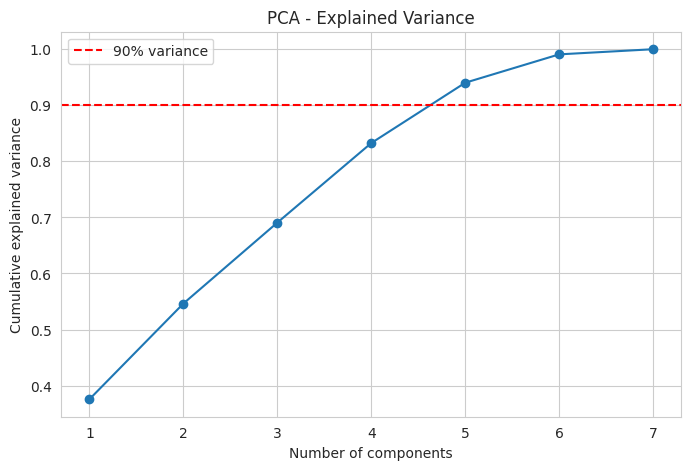

Components needed for >=90% variance: 5


In [3]:
pca_full = PCA().fit(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA - Explained Variance')
plt.legend()
plt.savefig('../reports/figures/pca_explained_variance.png', dpi=120)
plt.show()

n_components = int(np.argmax(explained >= 0.90) + 1)
print('Components needed for >=90% variance:', n_components)

In [4]:
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Reduced shape:', X_pca.shape)
print('Explained variance ratio:', pca.explained_variance_ratio_)

Reduced shape: (778, 5)
Explained variance ratio: [0.37563035 0.17069792 0.14434675 0.141925   0.10761483]


## 3. Find optimal K (Elbow Method + Silhouette Score)

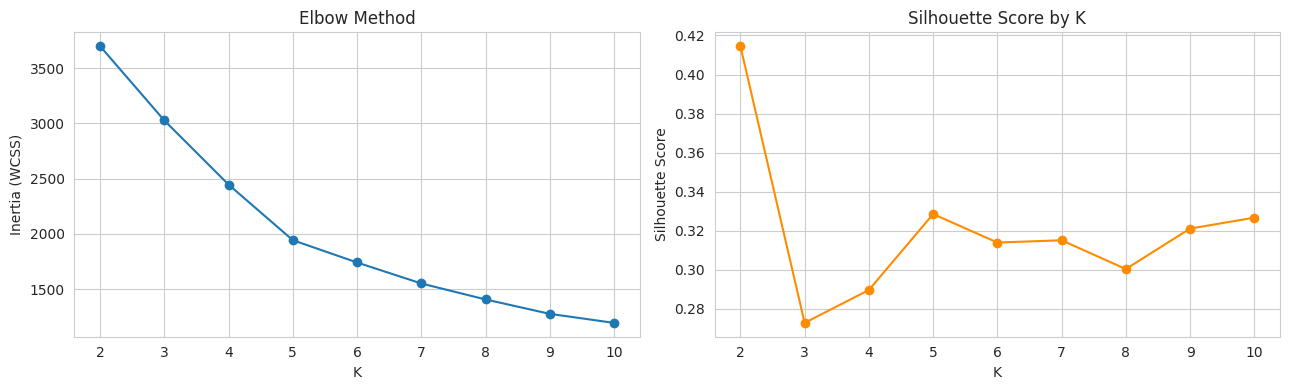

Best K by silhouette score: 2


In [5]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../reports/figures/elbow_silhouette.png', dpi=120)
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print('Best K by silhouette score:', best_k)

## 4. Fit final K-Means model

In [6]:
K_FINAL = best_k  # can be manually overridden after reviewing the plots above

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, customer_df['Cluster'])
db = davies_bouldin_score(X_pca, customer_df['Cluster'])
print(f'K = {K_FINAL} | Silhouette Score = {sil:.3f} | Davies-Bouldin Index = {db:.3f}')

customer_df['Cluster'].value_counts().sort_index()

K = 2 | Silhouette Score = 0.415 | Davies-Bouldin Index = 1.328


Cluster
0    135
1    643
Name: count, dtype: int64

## 5. Visualize clusters (2D PCA projection)

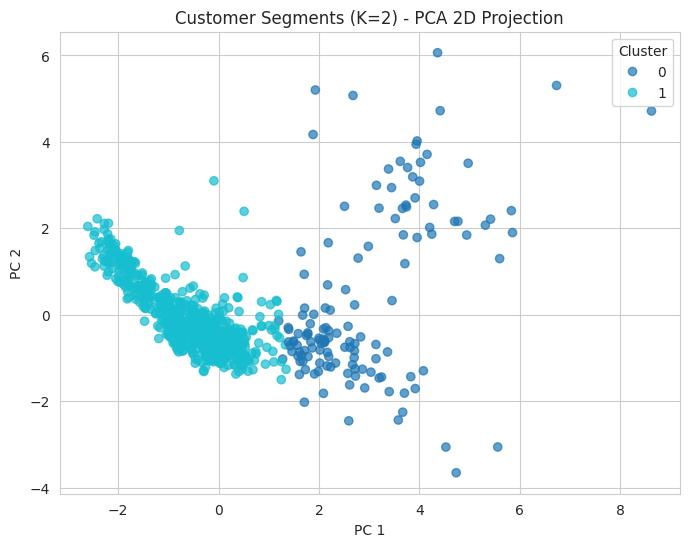

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=customer_df['Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'Customer Segments (K={K_FINAL}) - PCA 2D Projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.savefig('../reports/figures/cluster_scatter_2d.png', dpi=120)
plt.show()

## 6. Cluster profiling (business interpretation)

In [8]:
profile = customer_df.groupby('Cluster')[feature_cols].mean().round(2)
profile['CustomerCount'] = customer_df['Cluster'].value_counts().sort_index()
profile

,Recency,Frequency,Monetary,AvgTransactionAmount,AccountBalance,Age,Gender_Male,CustomerCount
Cluster,,,,,,,,
0,28.88,14.41,175372.13,14635.75,146512.41,41.96,0.40,135
1,85.66,6.31,14885.39,2036.49,37580.80,41.03,0.45,643


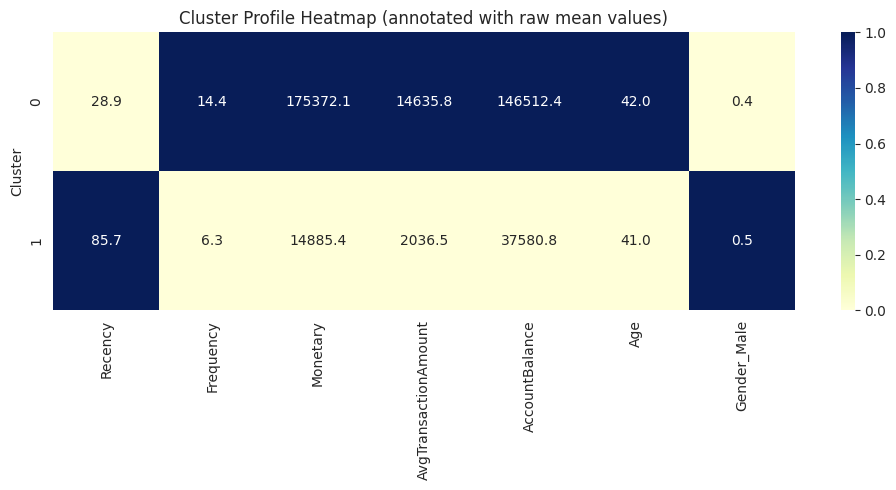

In [9]:
fig, ax = plt.subplots(figsize=(10,5))
profile_norm = (profile[feature_cols] - profile[feature_cols].min()) / \
               (profile[feature_cols].max() - profile[feature_cols].min())
sns.heatmap(profile_norm, annot=profile[feature_cols].values, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Cluster Profile Heatmap (annotated with raw mean values)')
plt.tight_layout()
plt.savefig('../reports/figures/cluster_profile_heatmap.png', dpi=120)
plt.show()

## 7. Business labels (example — adjust based on your actual profile output)

After reviewing the profile table above, assign human-readable labels, e.g.:
- **High-value loyal customers**: high Monetary & Frequency, low Recency
- **At-risk / dormant customers**: high Recency, low Frequency
- **New / low-activity customers**: low Frequency, moderate Recency
- **Budget-conscious customers**: low Monetary & AccountBalance


## 8. Save cluster assignments + model artifacts

In [10]:
customer_df.to_csv('../data/processed/customer_segments.csv', index=False)

joblib.dump(scaler, '../app/scaler.joblib')
joblib.dump(pca, '../app/pca.joblib')
joblib.dump(kmeans, '../app/kmeans_model.joblib')
joblib.dump(feature_cols, '../app/feature_cols.joblib')

print('Saved: customer_segments.csv, scaler.joblib, pca.joblib, kmeans_model.joblib')

Saved: customer_segments.csv, scaler.joblib, pca.joblib, kmeans_model.joblib
